In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [50]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [51]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
712,9661-JALZV,Female,0,No,No,58,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),24.70,1519,No
1713,1702-CCFNJ,Male,0,Yes,No,52,Yes,Yes,DSL,No,...,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),61.35,3169.55,No
3013,2065-MMKGR,Female,0,No,No,29,Yes,Yes,DSL,No,...,No,No,Yes,Yes,One year,Yes,Credit card (automatic),71.00,2080.1,No
6632,9259-PACGQ,Female,0,Yes,No,34,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Electronic check,62.65,2274.9,Yes


In [52]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [53]:
df_org.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [54]:
df=df_org.copy()

In [55]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

multi_cols = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [56]:
X = df.drop('Churn', axis=1)
Y = df['Churn']

In [57]:
Y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [58]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [59]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.linear_model import LogisticRegression



num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [70]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [71]:
pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', LogisticRegression())])

In [76]:
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
lr = LogisticRegression()

dt = DecisionTreeClassifier()

rf = RandomForestClassifier()

nb = GaussianNB()

svm = SVC(probability=True)


In [78]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report

)

In [91]:

ensemble_models = {

    # -------------------------------------
    # BAGGING
    # -------------------------------------

    'Bagging':

        BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            n_estimators=100,
            random_state=42
        ),

    # -------------------------------------
    # BOOSTING
    # -------------------------------------

    'AdaBoost':

        AdaBoostClassifier(
            n_estimators=100,
            random_state=42
        ),

    'Gradient Boosting':

        GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),

    # -------------------------------------
    # RANDOM FOREST
    # (Bagging + Random Feature Selection)
    # -------------------------------------

    'Random Forest':

        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    # -------------------------------------
    # VOTING CLASSIFIER
    # -------------------------------------

    'Voting':

        VotingClassifier(

            estimators=[

                ('lr', lr),

                ('rf', rf),

                ('svm', svm)

            ],

            voting='soft'
        ),

    # -------------------------------------
    # STACKING
    # -------------------------------------

    'Stacking':

        StackingClassifier(

            estimators=[

                ('lr', lr),

                ('rf', rf),

                ('svm', svm)

            ],

            final_estimator=LogisticRegression()

        )

}

# =========================================
# TRAIN + EVALUATE
# =========================================

for name, model in ensemble_models.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    # Pipeline
    pipe = Pipeline([

        (
            'cleaning',
            FunctionTransformer(basic_cleaning)
        ),

        (
            'preprocessing',
            preprocessor
        ),

        (
            'model',
            model
        )

    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    print(
        "Accuracy:",
        accuracy_score(y_test, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_test, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_test, y_pred)
    )

    print(
        "F1 Score:",
        f1_score(y_test, y_pred)
    )
results = []

results.append({

        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1

    })

results_df = pd.DataFrame(results)

print(results_df)





Bagging
Accuracy: 0.7799858055358411
Precision: 0.622568093385214
Recall: 0.4289544235924933
F1 Score: 0.5079365079365079


AdaBoost
Accuracy: 0.8133427963094393
Precision: 0.6821192052980133
Recall: 0.5522788203753352
F1 Score: 0.6103703703703703


Gradient Boosting
Accuracy: 0.8090844570617459
Precision: 0.6721854304635762
Recall: 0.5442359249329759
F1 Score: 0.6014814814814815


Random Forest
Accuracy: 0.7920511000709723
Precision: 0.6492537313432836
Recall: 0.46648793565683644
F1 Score: 0.5429017160686428


Voting
Accuracy: 0.808374733853797
Precision: 0.6958174904942965
Recall: 0.4906166219839142
F1 Score: 0.5754716981132075


Stacking
Accuracy: 0.8176011355571328
Precision: 0.6946308724832215
Recall: 0.5549597855227882
F1 Score: 0.61698956780924
      Model  Accuracy  Precision    Recall  F1 Score
0  Stacking  0.816182   0.686275  0.563003  0.618557




Bagging
Accuracy : 0.7799858055358411
Precision: 0.7188361300259403
Recall   : 0.6676625399815749
F1 Score : 0.6831273033284002


AdaBoost
Accuracy : 0.8133427963094393
Precision: 0.7656305150247971
Recall   : 0.7298073638556213
F1 Score : 0.7438226093569071


Gradient Boosting
Accuracy : 0.8090844570617459
Precision: 0.759308614057443
Recall   : 0.7243380396865652
F1 Score : 0.7379782582395742


Random Forest
Accuracy : 0.7920511000709723
Precision: 0.737422658835533
Recall   : 0.6878771724616228
F1 Score : 0.7041564161418088


Voting
Accuracy : 0.8055358410220014
Precision: 0.7612120194728891
Recall   : 0.7013363420870123
F1 Score : 0.7205563018981551


Stacking
Accuracy : 0.8168914123491838
Precision: 0.7713790713790714
Recall   : 0.7330783483598498
F1 Score : 0.7479238783118094


               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.779986   0.718836  0.667663  0.683127
1           AdaBoost  0.813343   0.765631  0.729807  0.743823
2  Gradient Boost

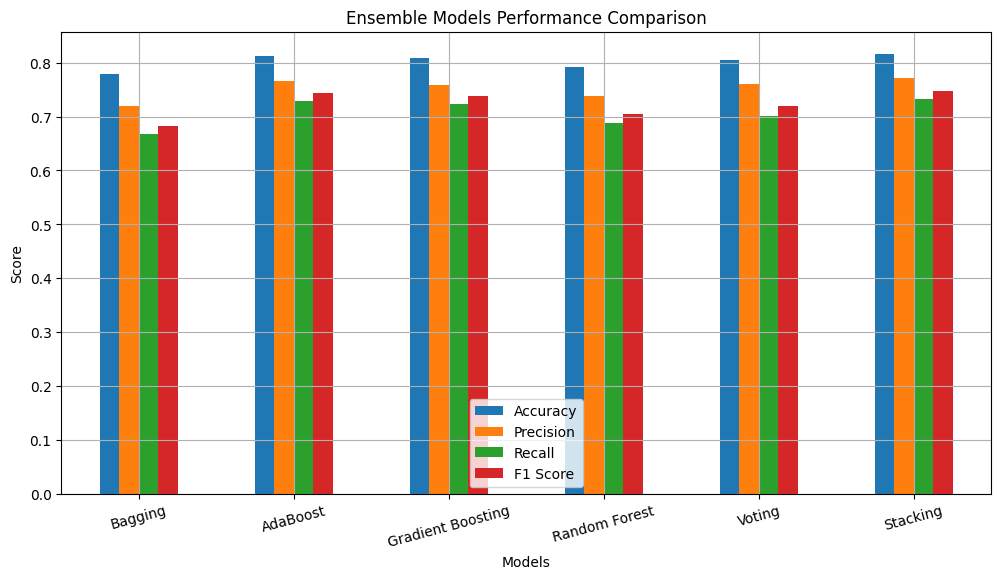

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# Store metrics
results = []

# =========================================
# TRAIN + EVALUATE
# =========================================

for name, model in ensemble_models.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    # Pipeline
    pipe = Pipeline([

        ('cleaning', FunctionTransformer(basic_cleaning)),

        ('preprocessing', preprocessor),

        ('model', model)

    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average='macro'
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    # Print Metrics
    print("Accuracy :", acc)

    print("Precision:", prec)

    print("Recall   :", rec)

    print("F1 Score :", f1)

    # Store Results
    results.append({

        'Model': name,

        'Accuracy': acc,

        'Precision': prec,

        'Recall': rec,

        'F1 Score': f1

    })

# =========================================
# RESULTS DATAFRAME
# =========================================

results_df = pd.DataFrame(results)

print("\n")
print(results_df)

# =========================================
# GRAPH
# =========================================

results_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(

    kind='bar',

    figsize=(12,6)

)

plt.title("Ensemble Models Performance Comparison")

plt.ylabel("Score")

plt.xlabel("Models")

plt.xticks(rotation=15)

plt.grid(True)

plt.legend(loc='best')

plt.show()


In [152]:
from xgboost import XGBClassifier
xgb = XGBClassifier(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=5,

    random_state=42
)
pipe = Pipeline([

    (
        'cleaning',
        FunctionTransformer(basic_cleaning)
    ),

    (
        'preprocessing',
        preprocessor
    ),

    (
        'model',
        xgb
    )

])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)

Accuracy: 0.8076650106458482
Precision: 0.6613924050632911
Recall: 0.5603217158176944
F1 Score: 0.6066763425253991




Bagging
Accuracy: 0.7799858055358411
Precision: 0.622568093385214
Recall: 0.4289544235924933
F1 Score: 0.5079365079365079


AdaBoost
Accuracy: 0.8133427963094393
Precision: 0.6821192052980133
Recall: 0.5522788203753352
F1 Score: 0.6103703703703703


Gradient Boosting
Accuracy: 0.8090844570617459
Precision: 0.6721854304635762
Recall: 0.5442359249329759
F1 Score: 0.6014814814814815


Random Forest
Accuracy: 0.7920511000709723
Precision: 0.6492537313432836
Recall: 0.46648793565683644
F1 Score: 0.5429017160686428


Voting
Accuracy: 0.8097941802696949
Precision: 0.6981132075471698
Recall: 0.4959785522788204
F1 Score: 0.5799373040752351


Stacking
Accuracy: 0.8161816891412349
Precision: 0.6862745098039216
Recall: 0.5630026809651475
F1 Score: 0.6185567010309279


               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.779986   0.622568  0.428954  0.507937
1           AdaBoost  0.813343   0.682119  0.552279  0.610370
2  Gradient Boosting  0.809084   0.672185  0.

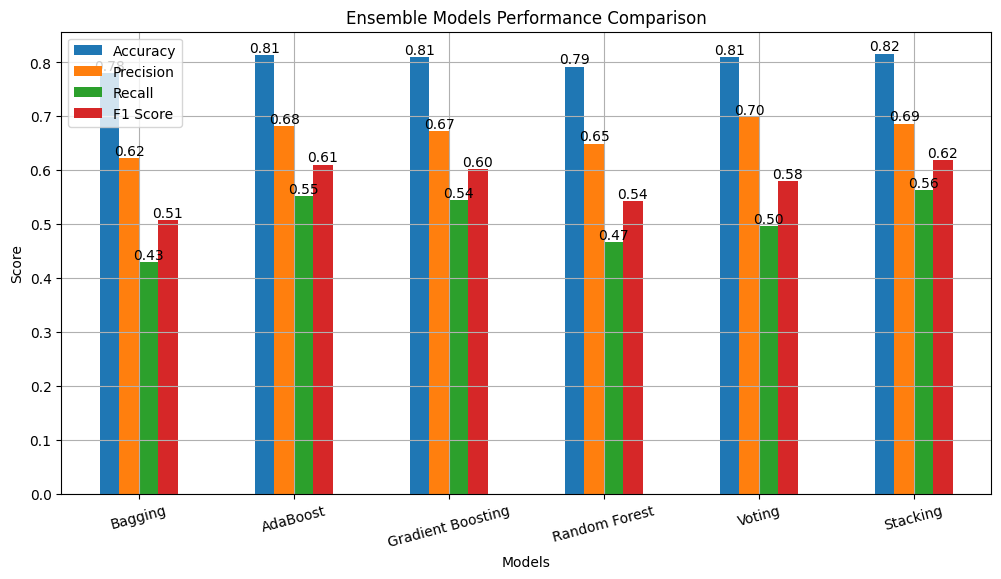

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Store metrics
results = []

# =========================================
# TRAIN + EVALUATE
# =========================================

for name, model in ensemble_models.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    # Pipeline
    pipe = Pipeline([

        ('cleaning', FunctionTransformer(basic_cleaning)),

        ('preprocessing', preprocessor),

        ('model', model)

    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(y_test, y_pred,average='binary')

    rec = recall_score(y_test, y_pred,average='binary')

    f1 = f1_score(y_test, y_pred,average='binary')

    # Print
    print("Accuracy:", acc)

    print("Precision:", prec)

    print("Recall:", rec)

    print("F1 Score:", f1)

    # Store results
    results.append({

        'Model': name,

        'Accuracy': acc,

        'Precision': prec,

        'Recall': rec,

        'F1 Score': f1

    })

# =========================================
# RESULTS DATAFRAME
# =========================================

results_df = pd.DataFrame(results)

print("\n")
print(results_df)

# =========================================
# GRAPH
# =========================================

ax = results_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(

    kind='bar',

    figsize=(12,6)

)

plt.title("Ensemble Models Performance Comparison")

plt.ylabel("Score")

plt.xlabel("Models")

plt.xticks(rotation=15)

plt.grid(True)

plt.legend(loc='best')

# value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()